In [1]:
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt 

from snudd         import config
from snudd.targets import Electron
from snudd.binding import binding_xe
from snudd.rrpa    import rrpa_scaling
from snudd.targets import Nucleus

from snudd.models       import GeneralNSI, SM

from snudd.resolution   import Resolution, Convolver # deals with the resolution effects on the rate
from snudd.resolution   import res_xnt_er
from snudd.resolution   import res_lz_nr

from snudd.efficiencies import efficiency_lz_b8 # efficiency 

In [2]:
efficiency_lz_b8(2.0*1e-6)

array(0.07992865)

In [3]:
xspace = np.linspace(0.0 , 10*1e-6, 100)
#plt.plot(xspace, efficiency_lz_b8(xspace), label="LZ B8 efficiency", ls='--')

In [4]:
def counts_LZB8_NR(signal, E_Rs):
    #### from https://arxiv.org/pdf/2512.08065 
    exposure =  5.7 # in tn yr-1
    convolution_lz_sig = Convolver(E_Rs, signal , efficiency_lz_b8, res_lz_nr)
    return convolution_lz_sig.convolved_binned_rate(1.0e-7, 1.5e-5)*exposure 

In [21]:
phispace = np.linspace(-np.pi/2, np.pi/2, 8) # phi domain
#eps_space = np.linspace(3.0, -3.0, 8) # epsilon domain
y_half = np.geomspace(0.01, 3.1, 10) 
eps_space = np.concatenate([-y_half[::-1], y_half]) 

phiGrid, epsGrid = np.meshgrid(phispace, eps_space, indexing='ij')

E_Rs = np.logspace(-2, 2, 1000) / 1e6  # Recoil energy in GeV, needed for the convolution to be broader than the bin considered

# ONE ISOTOPE

In [22]:
# Xenon-132
Xe_nucleus = Nucleus(54, 132, mass=131.9041535 * config.u)
N_LZ = np.zeros(np.shape(phiGrid))
Tstat_LZ = np.zeros(np.shape(phiGrid))

In [23]:
# Define SM spectrum
sm_model = SM()

Xe_nucleus.update_model(sm_model)
    
# Compute solar density matrix
Xe_nucleus.prepare_density()

# Calculate theoretical rate
sm_spec_NR = Xe_nucleus.spectrum(E_Rs)

# Compute events in experiments
N_LZ_sm    = counts_LZB8_NR(np.array(sm_spec_NR).T, E_Rs)

## NSI event loop

In [24]:
from snudd.nsi import utils

def set_NSI_params(eps, eta, phi):
    
    eps_matrix = np.array([[0., 1.0, 0.], [0., 0, 0.], [0., 0, 0.0]]) * eps # eps_{e\mu} can change this structure 
    eps_matrix = utils.eps_matrix_sym(eps_matrix)
    nsi_model = GeneralNSI(eps_matrix, eta, phi)
    
    return nsi_model

In [25]:
def a_min(alpha_a, mu, n_obs):
    a = 1
    b = (1 + alpha_a**2 * mu)
    c = alpha_a**2 * (mu - n_obs)
    return (-b + np.sqrt(b**2 - 4*a*c)) / 2



def t_mu_a(alpha_a, mu, n_obs):
    """Return the t_mu statistic given an expected number of events and the SM expectation (which we regard
    as the observation).
    """
    a = a_min(alpha_a, mu, n_obs)
    mu *= (1 + a)
    return 2 * (mu + n_obs*(np.log(n_obs / mu) - 1)) + (a / alpha_a)**2

In [34]:
from   multiprocess import Pool

parallel = True
nproc = 8 # Number of parallel processesix =

# Construct index list for grid computation
args  = []
for i in range(len(phispace)):
    for j in range(len(eps_space)):
        args.append((i,j))

def calc_events(n):
    """Calculate the number of signal events in LZ (and Xenon) for the grid point (i,j)"""

    i, j = args[n]

    NSI_eta = 0.0
    NSI_model_tmp = set_NSI_params(epsGrid[i,j], NSI_eta, phiGrid[i,j])
    
    #Xe_electron.update_model(NSI_model_tmp)
    Xe_nucleus.update_model(NSI_model_tmp)
    
    # Compute solar density matrix
    #Xe_electron.prepare_density()
    Xe_nucleus.prepare_density()

    # Calculate theoretical rate
    tmp_spec_NR = Xe_nucleus.spectrum(E_Rs)
    #tmp_spec_ER = Xe_electron.spectrum(E_Rs)

    # Compute events in experiments
    N_LZ_tmp    = counts_LZB8_NR(np.array(tmp_spec_NR).T, E_Rs)
    #N_xnt22_tmp = counts_xnt_ER(np.array(tmp_spec_ER).T, E_Rs)

    return i, j, N_LZ_tmp #N_xnt22_tmp



# Run in parallel mode
if parallel:
    with Pool(processes = nproc) as P:  
        # P.starmap(calc_events, args)
        for result in tqdm(P.imap_unordered(calc_events, range(len(args))), total=len(args), desc='Grid points'):
            # print(result)
            i, j, N_LZ_tmp = result
            N_LZ[i, j]     = np.real(N_LZ_tmp)
            Tstat_LZ[i,j]  = t_mu_a(0.12, np.real(N_LZ_tmp), N_LZ_sm) # 12% 8B
            #N_xnt22[i,j] = N_xnt22_tmp

# Run in serial mode
else:
    for n in tqdm(range(len(args)), desc='Grid points'):
        i, j, N_LZ_tmp = calc_events(n)
        N_LZ[i, j]     = np.real(N_LZ_tmp)
        Tstat_LZ[i,j]  = t_mu_a(0.12, np.real(N_LZ_tmp), N_LZ_sm) # 12% 8B
        #N_xnt22[i,j] = N_xnt22_tmp


Grid points:   0%|                                                                    | 0/160 [00:00<?, ?it/s]/tmp/ipykernel_2180585/1236918672.py:47: ComplexWarning: Casting complex values to real discards the imaginary part
  Tstat_LZ[i,j]  = t_mu_a(0.12, np.real(N_LZ_tmp), N_LZ_sm) # 12% 8B
Grid points:   2%|█▌                                                          | 4/160 [00:06<03:05,  1.19s/it]/tmp/ipykernel_2180585/1236918672.py:47: ComplexWarning: Casting complex values to real discards the imaginary part
  Tstat_LZ[i,j]  = t_mu_a(0.12, np.real(N_LZ_tmp), N_LZ_sm) # 12% 8B
/tmp/ipykernel_2180585/1236918672.py:47: ComplexWarning: Casting complex values to real discards the imaginary part
  Tstat_LZ[i,j]  = t_mu_a(0.12, np.real(N_LZ_tmp), N_LZ_sm) # 12% 8B
Grid points:   6%|███▍                                                        | 9/160 [00:11<02:46,  1.10s/it]/tmp/ipykernel_2180585/1236918672.py:47: ComplexWarning: Casting complex values to real discards the imaginary part

Text(0.5, 0, '$\\varphi$')

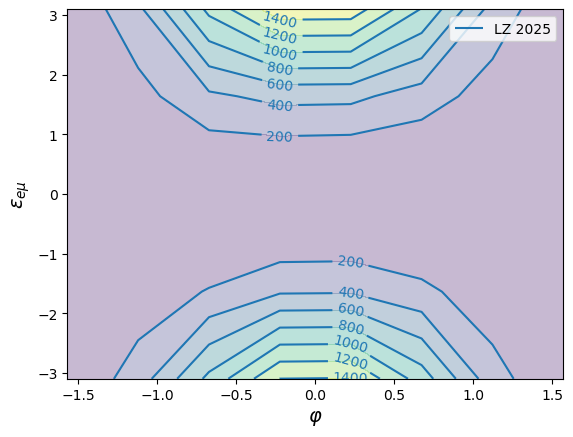

In [35]:
fig, ax = plt.subplots()

plt.contourf(phiGrid, epsGrid, N_LZ, alpha=0.3) 
contLZ = plt.contour(phiGrid, epsGrid, N_LZ, colors='tab:blue') 

plt.clabel(contLZ, inline=1, fontsize=10)

h1,l1 = contLZ.legend_elements()
plt.legend([h1[0]], ["LZ 2025"])

plt.ylabel(r'$\varepsilon_{e\mu}$', size=14)
plt.xlabel(r'$\varphi$', size=14)

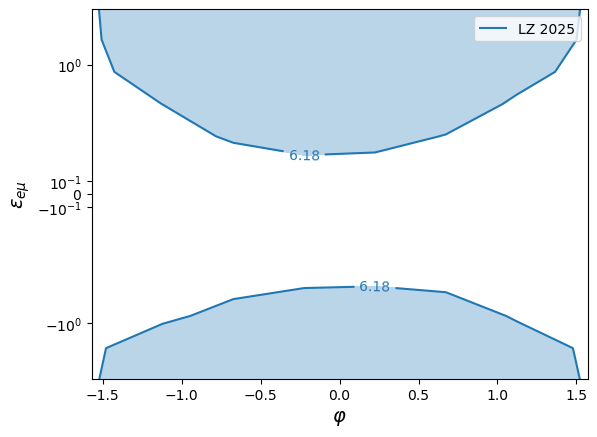

In [39]:
fig, ax = plt.subplots()

plt.contourf(phiGrid, epsGrid, Tstat_LZ, levels=[6.18,np.inf], colors='tab:blue', alpha=0.3) 
contLZ = plt.contour(phiGrid, epsGrid, Tstat_LZ, levels=[6.18], colors='tab:blue') 

plt.clabel(contLZ, inline=1, fontsize=10)

h1,l1 = contLZ.legend_elements()
plt.legend([h1[0]], ["LZ 2025"])

ax.set_yscale('symlog', linthresh=0.1, linscale=0.1)
ax.set_ylim(-3, 3)
plt.ylabel(r'$\varepsilon_{e\mu}$', size=14)
plt.xlabel(r'$\varphi$', size=14)
plt.savefig("eps_emu_LL.pdf", bbox_inches='tight')




# Save data to file
#np.savetxt("events_LZ25.csv", np.array([epsGrid, phiGrid, N_LZ, Tstat_LZ]), header="2D data grids: eps, phi, nevents, test_stat", delimiter=",")
np.save("events_LZ25.npy", np.array([epsGrid, phiGrid, N_LZ, Tstat_LZ]))